# Метрические алгоритмы

## Задание 1: Визуализация данных о пингвинах

В этом задании мы познакомимся с датасетом Palmer Penguins и проведем 
разведочный анализ данных, подготовив их для задачи классификации с 
помощью алгоритма k-NN.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Настройка для отображения графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [14]:
data = pd.read_csv("../../production/AI_Machine_Learning.Project_2.ID_1577772/datasets/penguins_size.csv")

In [ ]:
print(f"Размерность датасета: {data.shape}")

In [15]:
data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [5]:
### 2. Разведочный анализ данных (EDA)


In [6]:
# Изучение признаков (столбцов)
print("Столбцы датасета:")
print(data.columns.tolist())
print("\nТипы данных:")
print(data.dtypes)


Столбцы датасета:
['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Типы данных:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [17]:
data["island"].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [18]:
data["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [19]:
# Проверка пропущенных значений
print("Пропущенные значения:")
print(data.isnull().sum())
print(f"\nОбщее количество пропущенных значений: {data.isnull().sum().sum()}")

Пропущенные значения:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Общее количество пропущенных значений: 18


In [8]:
# Удаление строк с пропущенными значениями
data_clean = data.dropna()
print(f"Размерность после удаления пропущенных значений: {data_clean.shape}")
print(f"Удалено строк: {data.shape[0] - data_clean.shape[0]}")


Размерность после удаления пропущенных значений: (334, 7)
Удалено строк: 10


In [9]:
# Основная статистическая информация о числовых признаках
print("Статистическая информация о числовых признаках:")
data_clean.describe()


Статистическая информация о числовых признаках:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,334.000000,334.000000,334.000000,334.000000
mean,43.994311,17.160479,201.014970,4209.056886
std,5.460521,1.967909,14.022175,804.836129
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.575000,18.700000,213.000000,4793.750000
max,59.600000,21.500000,231.000000,6300.000000


In [10]:
# Определение признаков (X) и целевой переменной (Y)
# Целевая переменная - это вид пингвина (species)
# Признаки - это числовые характеристики пингвинов

# Целевая переменная
y = data_clean['species']
print("Целевая переменная (Y):")
print(y.value_counts())
print(f"\nКоличество классов: {y.nunique()}")

# Признаки (исключаем species, island, sex - они не числовые или не нужны)
# Для классификации используем числовые признаки
feature_columns = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = data_clean[feature_columns]

print("\nПризнаки (X):")
print(X.columns.tolist())
print(f"\nРазмерность X: {X.shape}")


Целевая переменная (Y):
species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

Количество классов: 3

Признаки (X):
['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

Размерность X: (334, 4)


### 3. Разделение данных на обучающую и тестовую выборки


In [11]:
# Разделение данных на train и test в соотношении 80% к 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Сохраняем пропорции классов в обеих выборках
)

print(f"Размер обучающей выборки (X_train): {X_train.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}")
print(f"Размер обучающей выборки (y_train): {y_train.shape}")
print(f"Размер тестовой выборки (y_test): {y_test.shape}")


Размер обучающей выборки (X_train): (267, 4)
Размер тестовой выборки (X_test): (67, 4)
Размер обучающей выборки (y_train): (267,)
Размер тестовой выборки (y_test): (67,)


In [12]:
# Проверка распределения классов в выборках
print("Распределение классов в обучающей выборке:")
print(y_train.value_counts())
print("\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts())


Распределение классов в обучающей выборке:
species
Adelie       117
Gentoo        96
Chinstrap     54
Name: count, dtype: int64

Распределение классов в тестовой выборке:
species
Adelie       29
Gentoo       24
Chinstrap    14
Name: count, dtype: int64


### 4. Визуализация данных


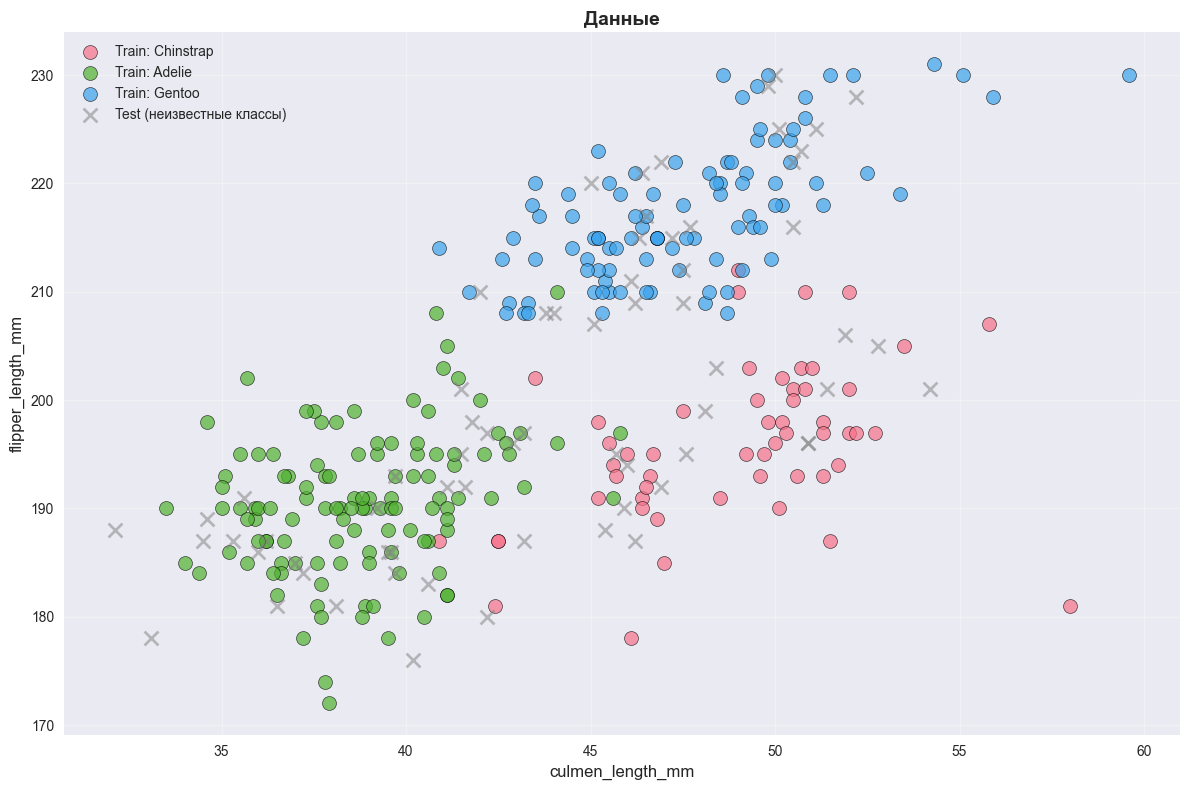

In [21]:
# Визуализация обучающей и тестовой выборок на одном графике
# Используем длину клюва (culmen_length_mm) и длину ласт (flipper_length_mm)

plt.figure(figsize=(12, 8))

# Получаем уникальные классы для цветовой схемы
unique_classes = y_train.unique()
colors = sns.color_palette("husl", len(unique_classes))
class_color_map = dict(zip(unique_classes, colors))

# Визуализация обучающей выборки (цветные точки по классам)
for species in unique_classes:
    mask = y_train == species
    plt.scatter(
        X_train[mask]['culmen_length_mm'], 
        X_train[mask]['flipper_length_mm'],
        c=[class_color_map[species]], 
        label=f'Train: {species}',
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )

# Визуализация тестовой выборки (серые точки)
plt.scatter(
    X_test['culmen_length_mm'], 
    X_test['flipper_length_mm'],
    c='gray', 
    label='Test (неизвестные классы)',
    alpha=0.5,
    s=100,
    marker='x',
    linewidth=2
)

plt.xlabel('culmen_length_mm', fontsize=12)
plt.ylabel('flipper_length_mm', fontsize=12)
plt.title('Данные', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()